# Comparing Sequential XGBoost and LSTM models

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, log_loss, roc_auc_score

XGB_FILE = Path("xgb_predictions.parquet")
LSTM_FILE = Path("lstm_every_minute_predictions.npz")

#### Helper Functions

In [5]:
def binary_metrics(y_true, probs):
    preds = (probs >= 0.5).astype(int)

    return {
        "auc": roc_auc_score(y_true, probs),
        "log_loss": log_loss(y_true, probs, labels=[0, 1]),
        "accuracy": accuracy_score(y_true, preds),
        "rows": len(y_true),
    }


def print_metrics(name, metrics):
    print(name)
    print("AUC:      ", round(metrics["auc"], 4))
    print("Log loss: ", round(metrics["log_loss"], 4))
    print("Accuracy: ", round(metrics["accuracy"], 4))
    print("Rows:     ", metrics["rows"])

## Load Predictions

In [ ]:
xgb = pd.read_parquet(XGB_FILE)

xgb = xgb.rename(columns={
    "pred_prob_team_100_win": "prob",
    "target": "y",
})

xgb = xgb[["match_id", "minute", "y", "prob"]].copy()
xgb["model"] = "XGBoost"

xgb.head()

lstm_data = np.load(LSTM_FILE, allow_pickle=True)

lstm_probs = lstm_data["probs_test"]
lstm_y = lstm_data["y_test"]
lstm_mask = lstm_data["mask_test"]

rows = []

for i in range(len(lstm_y)):
    for t in range(lstm_probs.shape[1]):
        if lstm_mask[i, t] == 1:
            rows.append({
                "match_index": i,
                "minute": t + 1,
                "y": int(lstm_y[i]),
                "prob": float(lstm_probs[i, t]),
                "model": "LSTM",
            })

lstm = pd.DataFrame(rows)

lstm.head()

## Comparison

In [ ]:
xgb_metrics = binary_metrics(xgb["y"], xgb["prob"])
lstm_metrics = binary_metrics(lstm["y"], lstm["prob"])

print_metrics("XGBoost every-minute", xgb_metrics)
print()
print_metrics("LSTM every-minute", lstm_metrics)

comparison = pd.DataFrame([
    {"model": "XGBoost", **xgb_metrics},
    {"model": "LSTM", **lstm_metrics},
])

comparison


XGBoost every-minute
AUC:       0.8076
Log loss:  0.5277
Accuracy:  0.718
Rows:      57833

LSTM every-minute
AUC:       0.7729
Log loss:  0.5609
Accuracy:  0.6853
Rows:      57591


,model,auc,log_loss,accuracy,rows
0,XGBoost,0.807550,0.527704,0.717964,57833
1,LSTM,0.772935,0.560933,0.685298,57591


## Evaluation by minute

In [ ]:
def add_minute_bucket(df):
    bins = [0, 5, 10, 15, 20, 25, 30, 45]
    labels = ["1-5", "6-10", "11-15", "16-20", "21-25", "26-30", "31-45"]

    df = df.copy()
    df["minute_bucket"] = pd.cut(
        df["minute"],
        bins=bins,
        labels=labels,
        include_lowest=True,
        right=True,
    )

    return df


xgb_b = add_minute_bucket(xgb)
lstm_b = add_minute_bucket(lstm)

both = pd.concat([xgb_b, lstm_b], ignore_index=True)

bucket_rows = []

for model_name, model_df in both.groupby("model"):
    for bucket, g in model_df.groupby("minute_bucket", observed=True):
        if len(g) == 0 or g["y"].nunique() < 2:
            continue

        metrics = binary_metrics(g["y"], g["prob"])

        bucket_rows.append({
            "model": model_name,
            "minute_bucket": bucket,
            **metrics,
        })

bucket_results = pd.DataFrame(bucket_rows)

bucket_results

,model,minute_bucket,auc,log_loss,accuracy,rows
0,LSTM,1-5,0.526829,0.691460,0.515403,9641
1,LSTM,6-10,0.627210,0.666325,0.584843,9382
2,LSTM,11-15,0.741406,0.598411,0.675690,9309
3,LSTM,16-20,0.820972,0.518517,0.739417,8953
4,LSTM,21-25,0.869953,0.456791,0.784453,8156
5,LSTM,26-30,0.888387,0.427848,0.811583,6406
6,LSTM,31-45,0.865854,0.471372,0.784123,5744
7,XGBoost,1-5,0.602358,0.673816,0.564919,11522
8,XGBoost,6-10,0.728377,0.608288,0.668731,9367
9,XGBoost,11-15,0.809155,0.530098,0.730207,9296


## AUC by minute bucket

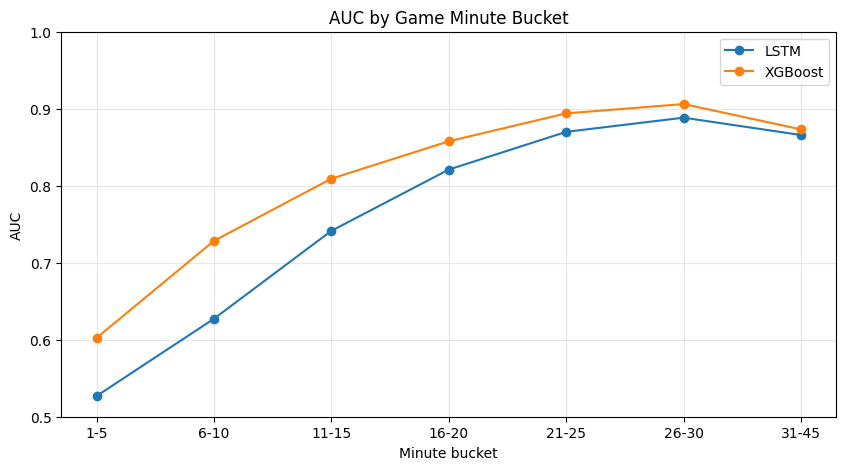

In [ ]:
plt.figure(figsize=(10, 5))

for model_name, g in bucket_results.groupby("model"):
    plt.plot(
        g["minute_bucket"].astype(str),
        g["auc"],
        marker="o",
        label=model_name,
    )

plt.title("AUC by Game Minute Bucket")
plt.xlabel("Minute bucket")
plt.ylabel("AUC")
plt.ylim(0.5, 1.0)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Accuracy by minute bucket

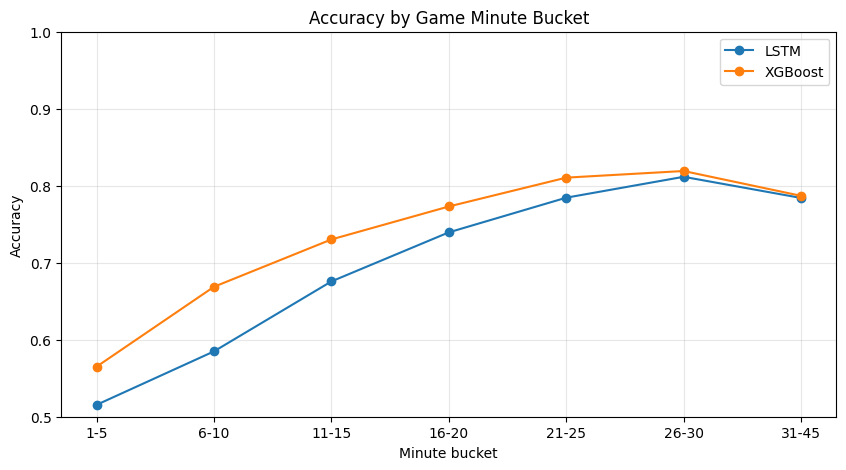

In [ ]:
plt.figure(figsize=(10, 5))

for model_name, g in bucket_results.groupby("model"):
    plt.plot(
        g["minute_bucket"].astype(str),
        g["accuracy"],
        marker="o",
        label=model_name,
    )

plt.title("Accuracy by Game Minute Bucket")
plt.xlabel("Minute bucket")
plt.ylabel("Accuracy")
plt.ylim(0.5, 1.0)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Probability Distribution

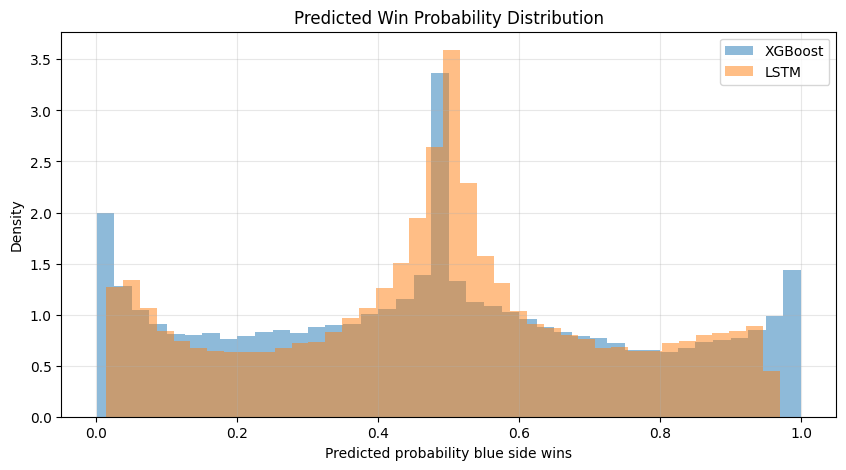

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    xgb["prob"],
    bins=40,
    alpha=0.5,
    label="XGBoost",
    density=True,
)

plt.hist(
    lstm["prob"],
    bins=40,
    alpha=0.5,
    label="LSTM",
    density=True,
)

plt.title("Predicted Win Probability Distribution")
plt.xlabel("Predicted probability blue side wins")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Confidence

In [ ]:
all_preds = pd.concat([xgb, lstm], ignore_index=True)

all_preds["confidence"] = (all_preds["prob"] - 0.5).abs() * 2

all_preds[["model", "minute", "y", "prob", "confidence"]].head()

all_preds.groupby("model")["confidence"].mean()

confidence_by_minute = (
    all_preds
    .groupby(["model", "minute"], as_index=False)
    .agg(confidence=("confidence", "mean"))
)

confidence_by_minute.head()

NameError: name 'pd' is not defined

In [ ]:
plt.figure(figsize=(10, 5))

for model in confidence_by_minute["model"].unique():
    g = confidence_by_minute[confidence_by_minute["model"] == model]

    plt.plot(
        g["minute"],
        g["confidence"],
        label=model,
    )

plt.xlabel("Minute")
plt.ylabel("Confidence")
plt.title("Average Confidence by Minute")
plt.ylim(0, 1)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## Summary

In [ ]:
summary = comparison[["model", "auc", "log_loss", "accuracy", "rows"]].copy()
summary = summary.sort_values("auc", ascending=False)

summary

,model,auc,log_loss,accuracy,rows
0,XGBoost,0.807550,0.527704,0.717964,57833
1,LSTM,0.772935,0.560933,0.685298,57591
